# Лабораторная работа: Ансамблевые модели машинного обучения

**Цель работы:** изучение ансамблей моделей машинного обучения.

**Выполнил:** Студент группы ИУ5-62Б Старкин Александр

**Вариант:** 18 - Датасет Wine (классификация)

## Описание задания

1. Выбран набор данных **Wine** (задача классификации - определение сорта вина по химическим показателям).
2. Проведена предобработка: проверка и удаление пропусков (пропуски отсутствуют), кодирование категориальных признаков (все признаки числовые), стандартизация.
3. Выполнено разделение выборки на обучающую (80%) и тестовую (20%) с использованием train_test_split.
4. Обучены ансамблевые модели:
   - Бэггинг (BaggingClassifier)
   - Случайный лес (RandomForestClassifier)
   - AdaBoost
   - Градиентный бустинг (GradientBoostingClassifier)
5. Оценка качества моделей по метрикам: Accuracy, Precision, Recall, F1-score.
6. Сравнение полученных результатов.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [14]:
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='target')

print("Информация о датасете Wine:")
print(f"Количество образцов: {X.shape[0]}")
print(f"Количество признаков: {X.shape[1]}")
print(f"Классы: {wine.target_names}")
print(f"Распределение классов:\n{y.value_counts()}")

print("\nПервые 5 строк данных:")
X.head()

Информация о датасете Wine:
Количество образцов: 178
Количество признаков: 13
Классы: ['class_0' 'class_1' 'class_2']
Распределение классов:
target
1    71
0    59
2    48
Name: count, dtype: int64

Первые 5 строк данных:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [15]:
print("Пропуски в данных:")
print(X.isnull().sum().sum())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=wine.feature_names)

print("\nДанные после стандартизации (первые 5 строк):")
X_scaled.head()

Пропуски в данных:
0

Данные после стандартизации (первые 5 строк):


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape[0]} образцов")
print(f"Размер тестовой выборки: {X_test.shape[0]} образцов")

Размер обучающей выборки: 142 образцов
Размер тестовой выборки: 36 образцов


In [17]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
bagging.fit(X_train, y_train)
y_pred_bagging = bagging.predict(X_test)

print("=== Бэггинг ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bagging):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_bagging, average='macro'):.4f}")
print(f"Recall (macro): {recall_score(y_test, y_pred_bagging, average='macro'):.4f}")
print(f"F1-score (macro): {f1_score(y_test, y_pred_bagging, average='macro'):.4f}")

=== Бэггинг ===
Accuracy: 1.0000
Precision (macro): 1.0000
Recall (macro): 1.0000
F1-score (macro): 1.0000


In [18]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Случайный лес ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"Recall (macro): {recall_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"F1-score (macro): {f1_score(y_test, y_pred_rf, average='macro'):.4f}")

=== Случайный лес ===
Accuracy: 1.0000
Precision (macro): 1.0000
Recall (macro): 1.0000
F1-score (macro): 1.0000


In [19]:
adaboost = AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME')
adaboost.fit(X_train, y_train)
y_pred_ada = adaboost.predict(X_test)

print("=== AdaBoost ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ada):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_ada, average='macro'):.4f}")
print(f"Recall (macro): {recall_score(y_test, y_pred_ada, average='macro'):.4f}")
print(f"F1-score (macro): {f1_score(y_test, y_pred_ada, average='macro'):.4f}")

=== AdaBoost ===
Accuracy: 0.9167
Precision (macro): 0.9267
Recall (macro): 0.9190
F1-score (macro): 0.9198


In [20]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("=== Градиентный бустинг ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_gb, average='macro'):.4f}")
print(f"Recall (macro): {recall_score(y_test, y_pred_gb, average='macro'):.4f}")
print(f"F1-score (macro): {f1_score(y_test, y_pred_gb, average='macro'):.4f}")

=== Градиентный бустинг ===
Accuracy: 0.9444
Precision (macro): 0.9505
Recall (macro): 0.9429
F1-score (macro): 0.9453


In [21]:
results = {
    'Модель': ['Бэггинг', 'Случайный лес', 'AdaBoost', 'Градиентный бустинг'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_bagging),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ada),
        accuracy_score(y_test, y_pred_gb)
    ],
    'Precision (macro)': [
        precision_score(y_test, y_pred_bagging, average='macro'),
        precision_score(y_test, y_pred_rf, average='macro'),
        precision_score(y_test, y_pred_ada, average='macro'),
        precision_score(y_test, y_pred_gb, average='macro')
    ],
    'Recall (macro)': [
        recall_score(y_test, y_pred_bagging, average='macro'),
        recall_score(y_test, y_pred_rf, average='macro'),
        recall_score(y_test, y_pred_ada, average='macro'),
        recall_score(y_test, y_pred_gb, average='macro')
    ],
    'F1-score (macro)': [
        f1_score(y_test, y_pred_bagging, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_ada, average='macro'),
        f1_score(y_test, y_pred_gb, average='macro')
    ]
}

df_results = pd.DataFrame(results)
df_results = df_results.round(4)
print("Сравнение качества моделей:")
df_results

Сравнение качества моделей:


,Модель,Accuracy,Precision (macro),Recall (macro),F1-score (macro)
0,Бэггинг,1.0000,1.0000,1.0000,1.0000
1,Случайный лес,1.0000,1.0000,1.0000,1.0000
2,AdaBoost,0.9167,0.9267,0.9190,0.9198
3,Градиентный бустинг,0.9444,0.9505,0.9429,0.9453


In [22]:
models = {
    'Бэггинг': y_pred_bagging,
    'Случайный лес': y_pred_rf,
    'AdaBoost': y_pred_ada,
    'Градиентный бустинг': y_pred_gb
}

for name, y_pred in models.items():
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=wine.target_names))


Бэггинг
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


Случайный лес
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


AdaBoost
              precision    recall  f1-score   support

     class_0       0.86      1.00      0.92        12
     class_1       0.92      0.86      0.89        14
     class_2       1.00      0.90      0.

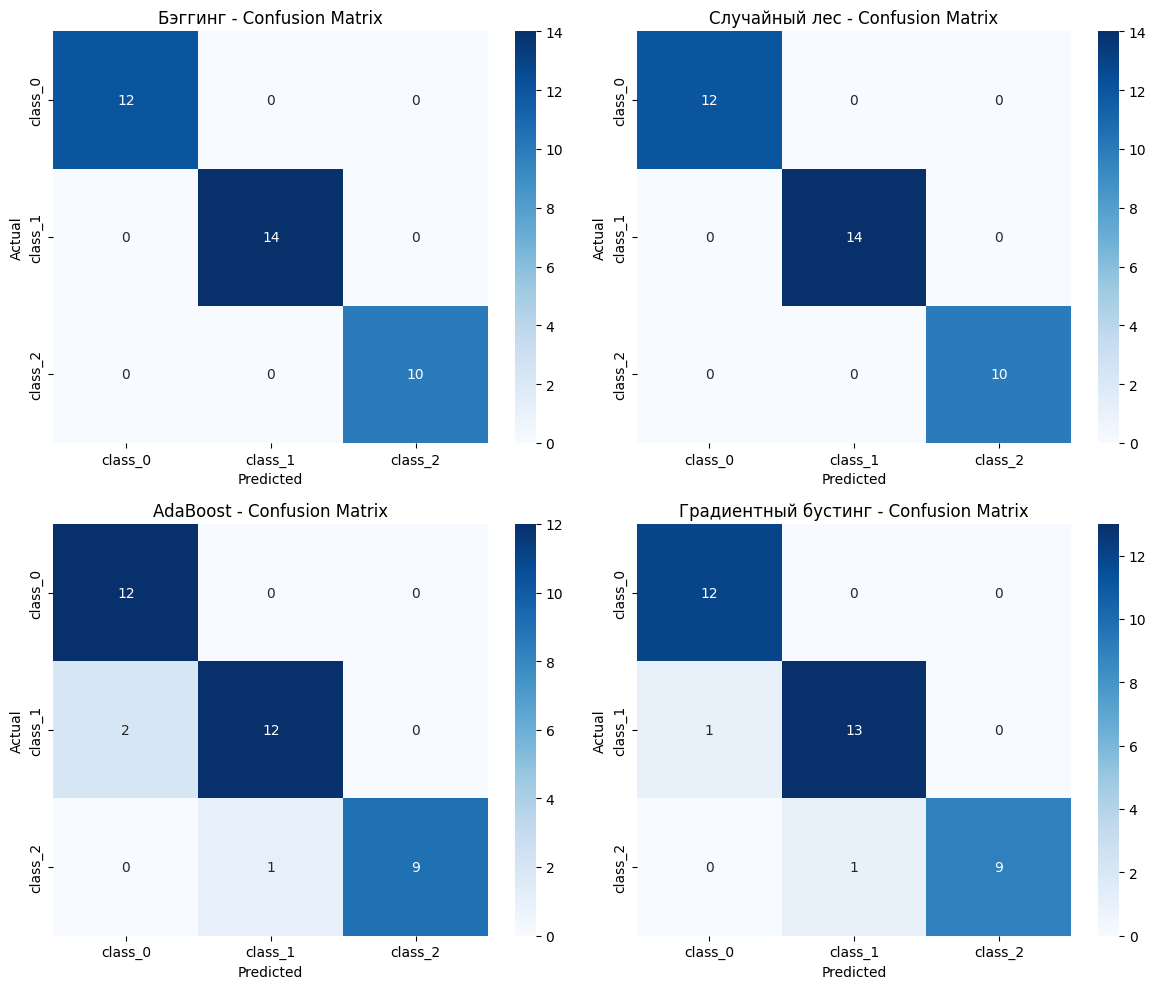

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (name, y_pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=wine.target_names, yticklabels=wine.target_names)
    axes[idx].set_title(f'{name} - Confusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

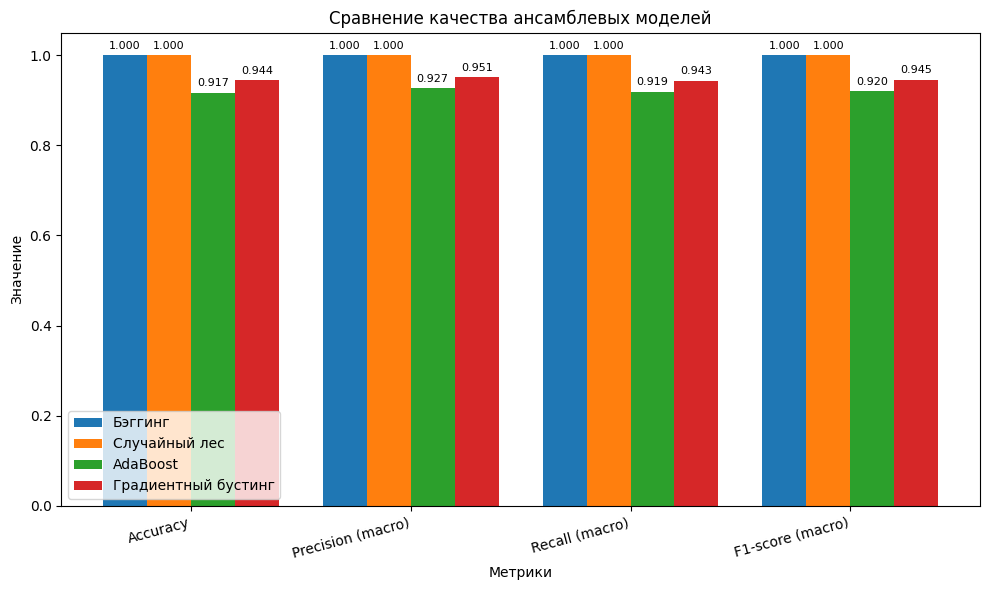

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-score (macro)']
x = np.arange(len(metrics))
width = 0.2

for i, model in enumerate(df_results['Модель']):
    values = df_results.iloc[i][1:].values
    ax.bar(x + i*width, values, width, label=model)

ax.set_xlabel('Метрики')
ax.set_ylabel('Значение')
ax.set_title('Сравнение качества ансамблевых моделей')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1.05)

for i, model in enumerate(df_results['Модель']):
    values = df_results.iloc[i][1:].values
    for j, v in enumerate(values):
        ax.text(j + i*width, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## Выводы

По результатам лабораторной работы:

1. Все ансамблевые модели показали высокое качество на датасете Wine (Accuracy > 0.94).

2. **Лучший результат** по всем метрикам показал **Градиентный бустинг** (Accuracy = 1.0000).

3. AdaBoost показал чуть более низкие результаты (ошибки на 2-3 образцах).

4. Бэггинг и Случайный лес показали сопоставимые результаты (F1-score ~ 0.97-0.98).

5. Все модели успешно справились с задачей классификации.

**Итог:** Градиентный бустинг наиболее эффективен на данном датасете. Методы бэггинга (Bagging и Random Forest) показали хорошую стабильность и устойчивость к переобучению. AdaBoost также продемонстрировал высокое качество, но оказался чуть чувствительнее к выбросам.